# **Lab 03.2 - Introduction to Deep Q-Network**

##### Copyright by UIT-NC@NT549

## **Some instructions before getting started**:
<div style="font-family: 'Arial'; font-size: 16px; line-height: 1.6; text-align: justify;">

Start the Kernel: At the top right, choose <strong>Select Kernel ➞ Python Environments...</strong>

You can run all code blocks to check: From the menu bar, choose <strong>Run All</strong>.

Complete all code blocks marked with the comment <span style="font-family: monospace; font-weight: bold; color:white; background-color: green;"> ### YOU NEED TO WRITE YOUR CODE BELOW ### </span>

This lab consists of 3 parts:
<ol style="margin-left: 20px;">
  <li><strong>Part 1: DQN on VacuumCleanerEnv</strong> - Custom environment with grid world and visual feedback</li>
  <li><strong>Part 2: DQN on LoadBalancingEnv</strong> - Multi-server task distribution problem</li>
  <li><strong>Part 3: Stable-Baselines3 DQN</strong> - Using production-ready RL library for faster implementation</li>
</ol>
</div>

### Imports and Setup

In [1]:
# ============================================================================
# Imports and runtime stability config
# ============================================================================

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random

# Reduce thread contention in notebook kernels (more stable on shared/limited CPUs).
# Guard set_num_interop_threads so this block is re-runnable in an existing kernel.
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    # Safe to ignore when interop threads were already configured earlier in this session.
    pass

# Fixed seeds => easier to compare student results across runs
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Use GPU if available; otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Quick diagnostic print so students can verify runtime environment
print(f"\n{'='*60}")
print(f"Device: {device}")
print(f"PyTorch Version: {torch.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Gymnasium Version: {gym.__version__}")
print(f"Torch Threads: {torch.get_num_threads()}")
print(f"{'='*60}\n")


Device: cpu
PyTorch Version: 2.11.0+cpu
NumPy Version: 2.4.2
Gymnasium Version: 1.2.3
Torch Threads: 1



---

# Shared Components for DQN

The following classes (ReplayBuffer, DQNNetwork, DQNAgent) are reused across all parts of this lab. They are modular and can be adapted for different environments.

### Shared Component 1: Replay Buffer

In [2]:
# ============================================================================
# Shared component: replay buffer
# ============================================================================
# Why this matters:
#+ DQN learns better from randomly sampled past experiences than from strictly
#+ consecutive transitions (which are highly correlated).

class ReplayBuffer:
    """Store and sample experiences for DQN training.

    A transition has shape: (state, action, reward, next_state, done)
    """

    def __init__(self, capacity=10000):
        """Create bounded memory for transitions.

        Args:
            capacity: Maximum transitions kept in memory.
        """
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Append one transition into replay memory."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Randomly sample a mini-batch and convert to tensors on target device.

        Returns:
            states, actions, rewards, next_states, dones
        """
        # Instruction:
        # 1) Use random.sample to get a batch of transitions from self.buffer
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        batch = random.sample(self.buffer, batch_size)

        # Instruction:
        # 1) Convert each component (state/action/reward/next_state/done) to NumPy arrays.
        # 2) Convert arrays to torch tensors on `device`.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states_np = np.array([t[0] for t in batch], dtype=np.float32)
        actions_np = np.array([t[1] for t in batch], dtype=np.int64)
        rewards_np = np.array([t[2] for t in batch], dtype=np.float32)
        next_states_np = np.array([t[3] for t in batch], dtype=np.float32)
        dones_np = np.array([t[4] for t in batch], dtype=np.float32)

        # 3) Convert numpy arrays to PyTorch tensors and move to device
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        states = torch.tensor(states_np, device=device)
        actions = torch.tensor(actions_np, device=device)
        rewards = torch.tensor(rewards_np, device=device)
        next_states = torch.tensor(next_states_np, device=device)
        dones = torch.tensor(dones_np, device=device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

print("✓ ReplayBuffer class defined")


✓ ReplayBuffer class defined


### Shared Component 2: DQN Network

In [3]:

# ============================================================================
# Shared component: Q-network
# ============================================================================
# This neural network approximates Q(s, a) for all actions a at once.

class DQNNetwork(nn.Module):
    """Simple MLP-based Deep Q-Network."""
    
    def __init__(self, state_size, action_size, hidden_size=64):
        """Initialize network layers.

        Args:
            state_size: Number of features in state vector.
            action_size: Number of discrete actions.
            hidden_size: Width of hidden layer (default 64).
        """
        super(DQNNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, action_size)
    
    def forward(self, state):
        """Compute Q-values for each possible action given a state batch."""
        x = self.fc1(state)
        x = self.relu(x)
        q_values = self.fc2(x)
        return q_values

print("✓ DQNNetwork class defined")


✓ DQNNetwork class defined


### Shared Component 3: DQN Agent

In [4]:

# ============================================================================
# Shared component: DQN agent
# ============================================================================

class DQNAgent:
    """Reusable Deep Q-Learning agent for discrete-action environments."""

    def __init__(self, state_size, action_size, learning_rate=1e-3, gamma=0.99):
        """Initialize model, optimizer, and replay memory.

        Args:
            state_size: State feature dimension.
            action_size: Number of valid actions.
            learning_rate: Adam learning rate.
            gamma: Reward discount factor.
        """
        self.state_size = state_size
        self.action_size = action_size
        self.gamma = gamma

        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995

        self.q_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network = DQNNetwork(state_size, action_size).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
        self.loss_fn = nn.MSELoss()

        self.replay_buffer = ReplayBuffer(capacity=10000)
        self.update_counter = 0

    def select_action(self, state, training=True):
        if training and random.random() < self.epsilon:
            return random.randint(0, self.action_size - 1)

        state_array = np.array(state, dtype=np.float32)
        state_tensor = torch.tensor(state_array, device=device).unsqueeze(0)

        with torch.no_grad():
            q_values = self.q_network(state_tensor)

        return q_values.argmax(dim=1).item()

    def store_transition(self, state, action, reward, next_state, done):
        state_array = np.array(state, dtype=np.float32)
        next_state_array = np.array(next_state, dtype=np.float32)
        self.replay_buffer.push(state_array, action, reward, next_state_array, done)

    def train_step(self, batch_size=32):
        if len(self.replay_buffer) < batch_size:
            return

        states, actions, rewards, next_states, dones = self.replay_buffer.sample(batch_size)

        q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = self.target_network(next_states).max(dim=1)[0]
            target_q_values = rewards + self.gamma * next_q_values * (1 - dones)

        loss = self.loss_fn(q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.update_counter += 1
        if self.update_counter % 100 == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """Decay epsilon after each episode, clamped at epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

print("✓ DQNAgent class defined")


✓ DQNAgent class defined


---

# PART 1: DQN on VacuumCleanerEnv

A custom grid-based environment where the agent must clean a 5x5 grid by visiting all dirty cells.

### 1.1: Define VacuumCleanerEnv

Custom Gymnasium environment for vacuum cleaning task.

In [ ]:
# ============================================================================
# Part 1 environment: VacuumCleanerEnv
# ============================================================================
# Problem setup:
#+ Grid world 5x5. Agent starts at cell 0.
#+ Every other cell is initially dirty.
#+ Goal: move and clean as many cells as possible before max_steps.

class VacuumCleanerEnv(gym.Env):
    """Grid-based vacuum cleaning task with discrete movement actions."""
    
    def __init__(self, grid_size=5):
        """Initialize environment dynamics and spaces."""
        super().__init__()
        self.grid_size = grid_size
        self.num_cells = grid_size * grid_size
        
        # Actions: 0=up, 1=down, 2=left, 3=right
        self.action_space = spaces.Discrete(4)
        
        # Observation = [one-hot position (25)] + [dirty-mask (25)] => length 50
        self.observation_space = spaces.Box(low=0, high=1, shape=(50,), dtype=np.float32)
        
        self.agent_pos = 0
        self.dirty_cells = set(range(1, self.num_cells))
        self.steps = 0
        self.max_steps = 100
        self.total_reward = 0.0
    
    def _get_state(self):
        """Encode current environment state as a float32 vector."""
        state = np.zeros(50, dtype=np.float32)
        
        # Position channel (one-hot)
        state[self.agent_pos] = 1.0
        
        # Dirt channel (binary mask)
        for cell in self.dirty_cells:
            state[25 + cell] = 1.0
        
        return state
    
    def reset(self, seed=None):
        """Reset to initial configuration for a new episode."""
        super().reset(seed=seed)
        self.agent_pos = 0
        self.dirty_cells = set(range(1, self.num_cells))
        self.steps = 0
        self.total_reward = 0.0
        return self._get_state(), {}
    
    def step(self, action):
        """Apply one action and return Gymnasium transition tuple."""
        self.steps += 1
        row, col = divmod(self.agent_pos, self.grid_size)
        
        # Apply bounded movement
        if action == 0:
            row = max(0, row - 1)
        elif action == 1:
            row = min(self.grid_size - 1, row + 1)
        elif action == 2:
            col = max(0, col - 1)
        elif action == 3:
            col = min(self.grid_size - 1, col + 1)
        
        self.agent_pos = row * self.grid_size + col
        
        # Reward design: +10 for cleaning new dirty cell, -0.1 otherwise
        if self.agent_pos in self.dirty_cells:
            self.dirty_cells.remove(self.agent_pos)
            reward = 10.0
        else:
            reward = -0.1
        
        self.total_reward += reward
        
        terminated = len(self.dirty_cells) == 0
        truncated = self.steps >= self.max_steps
        
        return self._get_state(), reward, terminated, truncated, {}
    
    def render(self, mode='human'):
        """Render environment as text grid.

        mode='human': print to notebook output
        mode='ansi' : return string for custom logging/animation
        """
        grid = [['.' for _ in range(self.grid_size)] for _ in range(self.grid_size)]
        
        # Mark dirty cells
        for cell in self.dirty_cells:
            r, c = divmod(cell, self.grid_size)
            grid[r][c] = 'D'
        
        # Mark agent
        r, c = divmod(self.agent_pos, self.grid_size)
        grid[r][c] = 'A'
        
        lines = [' '.join(row) for row in grid]
        cleaned = (self.num_cells - 1) - len(self.dirty_cells)
        clean_ratio = cleaned / (self.num_cells - 1)
        lines.append(f"Steps: {self.steps}/{self.max_steps} | Cleaned: {cleaned}/{self.num_cells - 1} ({clean_ratio:.1%}) | Total reward: {self.total_reward:.2f}")
        text = '\n'.join(lines)
        
        if mode == 'ansi':
            return text
        print(text)
        print()

print("✓ VacuumCleanerEnv class defined")

### 1.2: Training DQN on VacuumCleanerEnv

In [ ]:
# ============================================================================
# Part 1 training loop
# ============================================================================
print("\n" + "="*60)
print("PART 1: DQN ON VACUUMCLEANERENV")
print("="*60)

print("\n1.2: Training on Custom VacuumCleanerEnv")
print("-" * 60)

env1 = VacuumCleanerEnv(grid_size=5)
agent1 = DQNAgent(state_size=50, action_size=4, learning_rate=1e-3)

num_episodes = 250
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env1.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # 1) Select action.
        # 2) Step environment.
        # 3) Store transition and train.
        # 4) Update state and counters.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent1.select_action(state, training=True)
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        agent1.store_transition(state, action, reward, next_state, done)
        agent1.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    agent1.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent1.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")


### 1.3: Evaluation and Visualization

In [ ]:
# ============================================================================
# Part 1 evaluation
# ============================================================================
# Tier-based evaluation:
# - Basic success: cleaned >= 20%
# - Good success : cleaned >= 50%
# - Full success : cleaned 100%

print("\n1.3: Evaluation on VacuumCleanerEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []
eval_clean_ratios = []
eval_full_completed = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for _ in range(eval_episodes):
    state, _ = env1.reset()
    episode_reward = 0.0
    done = False
    terminated = False

    while not done:
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = None
        next_state, reward, terminated, truncated, _ = env1.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state

    cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
    clean_ratio = cleaned / (env1.num_cells - 1)
    eval_rewards.append(episode_reward)
    eval_clean_ratios.append(clean_ratio)
    eval_full_completed.append(bool(terminated))

# Instruction:
# Compute average reward, average clean ratio, and success rates for each tier...
### YOU NEED TO WRITE YOUR CODE BELOW ###
basic_success_rate = None
good_success_rate = None
full_completion_rate = None
avg_clean_ratio = None

print("Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Average Clean Ratio: {avg_clean_ratio:.1f}%")
print(f"  Basic Success Rate (>=20% cleaned): {basic_success_rate:.1f}%")
print(f"  Good Success Rate (>=50% cleaned): {good_success_rate:.1f}%")
print(f"  Full Completion Rate (100% cleaned): {full_completion_rate:.1f}%")
print(f"  Min/Max Reward: {np.min(eval_rewards):.2f} / {np.max(eval_rewards):.2f}")


### 1.4: Policy Rollout Demo (Greedy)

In [ ]:
# Show one greedy rollout to visualize the learned policy behavior
print("\n1.4: Policy Rollout Demo (Greedy)")
print("-" * 60)

action_names = {0: "UP", 1: "DOWN", 2: "LEFT", 3: "RIGHT"}

state, _ = env1.reset(seed=123)
done = False
demo_reward = 0.0
demo_max_steps = 12  # Keep output compact but informative
step_id = 0

print("Initial state:")
print(env1.render(mode='ansi'))
print()

while (not done) and (step_id < demo_max_steps):
    action = agent1.select_action(state, training=False)
    next_state, reward, terminated, truncated, _ = env1.step(action)
    done = terminated or truncated
    step_id += 1
    demo_reward += reward
    
    print(f"Step {step_id:02d} | Action: {action_names[action]:>5} | Reward: {reward:>5.1f} | Done: {done}")
    print(env1.render(mode='ansi'))
    print()
    
    state = next_state

cleaned = (env1.num_cells - 1) - len(env1.dirty_cells)
clean_ratio = cleaned / (env1.num_cells - 1)
print("Demo summary:")
print(f"  Total reward: {demo_reward:.2f}")
print(f"  Cleaned: {cleaned}/{env1.num_cells - 1} ({clean_ratio:.1%})")
print(f"  Full completion: {'Yes' if len(env1.dirty_cells) == 0 else 'No'}")

In [ ]:
# ============================================================================
# Part 1 visualization
# ============================================================================
# Left plot: training rewards + moving average
# Right plot: distribution by cleaning-quality tiers

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training curve
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='blue')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='red', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 1: VacuumCleanerEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: quality tiers based on clean ratio
clean_ratios = np.array(eval_clean_ratios)
tier_labels = ['<20%', '20-50%', '50-99%', '100%']
tier_counts = [
    int(np.sum(clean_ratios < 0.20)),
    int(np.sum((clean_ratios >= 0.20) & (clean_ratios < 0.50))),
    int(np.sum((clean_ratios >= 0.50) & (clean_ratios < 1.00))),
    int(np.sum(clean_ratios >= 1.00))
]
tier_colors = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']

axes[1].bar(tier_labels, tier_counts, color=tier_colors)
axes[1].set_ylabel('Number of Episodes')
axes[1].set_title(
    f'Evaluation Quality Tiers | Avg Clean: {avg_clean_ratio:.1f}% | Basic Success: {basic_success_rate:.1f}%',
    fontsize=10,
    fontweight='bold'
 )
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory in notebook runtime

### Part 1 Improvement Challenge (Target: Success Rate > 80%)

Use your DQN implementation and try to improve performance with the following ideas:

1. **Reward redesign**
   - Add stronger penalty for wall hits / repeated visits to old cells.
   - Add larger bonus when the agent cleans all cells.

2. **Q-network architecture**
   - Try hidden sizes: `64 / 128 / 256`.
   - Try deeper MLP (more hidden layers).

3. **Hyperparameter tuning**
   - `learning_rate`
   - `batch_size = 32 / 64`
   - `epsilon_decay = 0.99 / 0.995 / 0.998`

Document the best setting that helps you reach **success rate > 80%**.


---

# PART 2: DQN on LoadBalancingEnv

A multi-server task distribution environment where the agent learns to distribute tasks optimally.

### 2.1: Define LoadBalancingEnv

In [ ]:
# ============================================================================
# Part 2 environment: LoadBalancingEnv
# ============================================================================
# Scenario: tasks arrive over time and must be assigned to one of many servers.
# Objective: minimize total queue length (proxy for waiting time / delay).

class Task:
    """Simple task object with processing demand."""
    def __init__(self, demand=10):
        self.demand = demand

class Server:
    """Server with queue and fixed processing speed per step."""
    def __init__(self, speed=1.0):
        self.speed = speed
        self.queue = 0
    
    def add_task(self, demand):
        """Increase queue by incoming task demand."""
        self.queue += demand
    
    def process(self):
        """Process queued work by speed amount each step."""
        self.queue = max(0, self.queue - self.speed)
    
    def get_utilization(self):
        """Normalized queue value in [0, 1]."""
        return min(1.0, self.queue / 100.0)

class LoadBalancingEnv(gym.Env):
    """Gymnasium environment for dynamic multi-server load balancing."""
    
    def __init__(self, num_servers=3):
        super().__init__()
        self.num_servers = num_servers
        self.servers = [Server(speed=1.0) for _ in range(num_servers)]
        
        # Action: choose one server index
        self.action_space = spaces.Discrete(num_servers)
        
        # Observation: utilization of each server
        self.observation_space = spaces.Box(low=0, high=1, shape=(num_servers,), dtype=np.float32)
        
        self.steps = 0
        self.max_steps = 300
    
    def _get_state(self):
        """Return current normalized server utilizations."""
        return np.array([s.get_utilization() for s in self.servers], dtype=np.float32)
    
    def reset(self, seed=None):
        """Reset all queues and episode step counter."""
        super().reset(seed=seed)
        self.servers = [Server(speed=1.0) for _ in range(self.num_servers)]
        self.steps = 0
        return self._get_state(), {}
    
    def step(self, action):
        """Assign one incoming task and advance all servers by one processing tick."""
        self.steps += 1
        
        # Random incoming workload (simulates traffic fluctuation)
        task_demand = np.random.randint(5, 15)
        
        # Route task to chosen server
        self.servers[action].add_task(task_demand)
        
        # Servers process queues in parallel
        for server in self.servers:
            server.process()
        
        # Reward penalizes large system queue
        total_queue = sum(s.queue for s in self.servers)
        reward = -total_queue / 100.0
        
        terminated = False
        truncated = self.steps >= self.max_steps
        
        return self._get_state(), reward, terminated, truncated, {}
    
    def get_round_robin_action(self):
        return self.steps % self.num_servers

print("✓ LoadBalancingEnv class defined")

✓ LoadBalancingEnv class defined


### 2.2: Training DQN on LoadBalancingEnv

In [ ]:
# ============================================================================
# Part 2 training loop
# ============================================================================
print("\n" + "="*60)
print("PART 2: DQN ON LOADBALANCINGNV")
print("="*60)

print("\n2.2: Training on LoadBalancingEnv")
print("-" * 60)

env2 = LoadBalancingEnv(num_servers=3)
agent2 = DQNAgent(state_size=3, action_size=3, learning_rate=1e-3)

num_episodes = 300
batch_size = 32

episode_rewards = []
episode_lengths = []

print(f"\nTraining for {num_episodes} episodes...\n")

for episode in range(num_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    step_count = 0
    done = False

    while not done:
        # Instruction:
        # Complete the DQN interaction loop for LoadBalancingEnv.
        ### YOU NEED TO WRITE YOUR CODE BELOW ###
        action = agent2.select_action(state, training=True)
        
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        agent2.store_transition(state, action, reward, next_state, done)
        agent2.train_step(batch_size)
        episode_reward += reward
        step_count += 1
        state = next_state

    agent2.decay_epsilon()
    episode_rewards.append(episode_reward)
    episode_lengths.append(step_count)

    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:3d}/{num_episodes} | Avg Reward (last 50): {avg_reward:.2f} | Epsilon: {agent2.epsilon:.3f}")

print(f"\nTraining completed!")
print(f"Final average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")


### 2.3: Evaluation and Visualization

In [ ]:
# ============================================================================
# Part 2 evaluation
# ============================================================================
# Greedy evaluation: check how well the learned routing policy minimizes queues.

print("\n2.3: Evaluation on LoadBalancingEnv")
print("-" * 60)

eval_episodes = 30
eval_rewards = []

print(f"\nEvaluating on {eval_episodes} episodes (greedy policy)...\n")

for episode in range(eval_episodes):
    state, _ = env2.reset()
    episode_reward = 0
    done = False
    
    while not done:
        action = agent2.select_action(state, training=False)
        next_state, reward, terminated, truncated, _ = env2.step(action)
        done = terminated or truncated
        episode_reward += reward
        state = next_state
    
    eval_rewards.append(episode_reward)

print(f"Evaluation Results:")
print(f"  Average Reward: {np.mean(eval_rewards):.2f}")
print(f"  Best Reward: {np.max(eval_rewards):.2f}")
print(f"  Worst Reward: {np.min(eval_rewards):.2f}")
print(f"  Std Dev: {np.std(eval_rewards):.2f}")

In [ ]:
# ============================================================================
# Part 2 visualization
# ============================================================================
# Left plot: episode rewards + moving average
# Right plot: distribution of evaluation rewards

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: training trend
axes[0].plot(episode_rewards, alpha=0.3, label='Episode Reward', color='green')
ma_window = 30
ma_rewards = np.convolve(episode_rewards, np.ones(ma_window)/ma_window, mode='valid')
axes[0].plot(range(ma_window-1, len(episode_rewards)), ma_rewards, label=f'MA({ma_window})', color='darkgreen', linewidth=2)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Episode Reward')
axes[0].set_title('Part 2: LoadBalancingEnv Training Progress', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: evaluation spread
axes[1].boxplot(eval_rewards, vert=True)
axes[1].set_ylabel('Episode Reward')
axes[1].set_title('Evaluation Reward Distribution', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
plt.close(fig)  # Free figure memory

### 2.5: Enhanced LoadBalancingEnv và Round Robin Policy

In [6]:

# ============================================================================
# Enhanced LoadBalancingEnv – state (5D), capacity, full metrics tracking
# RoundRobinAgent – deterministic baseline policy
# ============================================================================

class EnhancedLoadBalancingEnv(gym.Env):
    """
    Enhanced Load Balancing Environment for DQN.

    State (5D for 3 servers):
        [q0/C, q1/C, q2/C, demand/MAX_DEMAND, step/max_steps]

    Capacity constraint:
        If queue_i + demand > CAPACITY  →  task is DROPPED (skipped).

    Reward (v1 – original, penalise queue + drop):
        r = −avg_queue_norm − 0.5 * drop_penalty
    """

    CAPACITY   = 100.0   # max queue depth per server (demand units)
    MIN_DEMAND =   5.0   # minimum task demand
    MAX_DEMAND =  20.0   # maximum task demand

    def __init__(self, num_servers=3, max_steps=300, reward_version='v1'):
        super().__init__()
        self.num_servers    = num_servers
        self.max_steps      = max_steps
        self.reward_version = reward_version

        self.action_space      = spaces.Discrete(num_servers)
        # [q₀/C … qₙ/C | demand/MAX | step/max]
        self.observation_space = spaces.Box(
            low=0.0, high=1.0,
            shape=(num_servers + 2,),
            dtype=np.float32
        )

        self.queues          = np.zeros(num_servers, dtype=np.float32)
        self.current_demand  = 0.0
        self.steps           = 0
        self._reset_metrics()

    # ------------------------------------------------------------------
    def _reset_metrics(self):
        self._m = {
            'tasks_created':       0,
            'tasks_accepted':      0,
            'tasks_skipped':       0,
            'completed_work':      0.0,
            'queue_sum':           0.0,
            'selection_count':     [0] * self.num_servers,
            'total_reward':        0.0,
            'queue_std_sum':       0.0,   # for load-deviation metric
        }

    # ------------------------------------------------------------------
    def _get_state(self):
        q_norm     = self.queues / self.CAPACITY
        d_norm     = self.current_demand / self.MAX_DEMAND
        step_norm  = self.steps / self.max_steps
        return np.concatenate([q_norm, [d_norm, step_norm]]).astype(np.float32)

    # ------------------------------------------------------------------
    def reset(self, seed=None):
        super().reset(seed=seed)
        self.queues         = np.zeros(self.num_servers, dtype=np.float32)
        self.steps          = 0
        rng                 = np.random.default_rng(seed)
        self.current_demand = float(rng.uniform(self.MIN_DEMAND, self.MAX_DEMAND))
        self._reset_metrics()
        return self._get_state(), {}

    # ------------------------------------------------------------------
    def step(self, action):
        self.steps += 1

        # --- generate incoming task ---
        task_demand           = float(np.random.uniform(self.MIN_DEMAND, self.MAX_DEMAND))
        self.current_demand   = task_demand
        self._m['tasks_created'] += 1
        self._m['selection_count'][action] += 1

        # --- route task (accept or drop) ---
        if self.queues[action] + task_demand <= self.CAPACITY:
            self.queues[action]      += task_demand
            self._m['tasks_accepted'] += 1
            accepted = True
        else:
            self._m['tasks_skipped'] += 1
            accepted = False

        # --- servers process in parallel (speed = 1 unit / step) ---
        processed = 0.0
        for i in range(self.num_servers):
            proc              = min(self.queues[i], 1.0)
            self.queues[i]    = max(0.0, self.queues[i] - 1.0)
            processed        += proc
        self._m['completed_work'] += processed

        # --- metrics bookkeeping ---
        total_q = float(np.sum(self.queues))
        self._m['queue_sum']    += total_q
        util                    = self.queues / self.CAPACITY
        self._m['queue_std_sum'] += float(np.std(util))

        # --- reward v1 ---
        avg_q_norm = total_q / (self.num_servers * self.CAPACITY)
        reward = -avg_q_norm + (-0.5 if not accepted else 0.0)

        self._m['total_reward'] += reward

        terminated = False
        truncated  = self.steps >= self.max_steps
        return self._get_state(), reward, terminated, truncated, {
            'accepted': accepted, 'demand': task_demand
        }

    # ------------------------------------------------------------------
    def get_episode_metrics(self):
        """Return a dict of all required metrics for the completed episode."""
        m   = self._m
        T   = max(self.steps, 1)
        avg_demand = (self.MIN_DEMAND + self.MAX_DEMAND) / 2.0

        return {
            'total_time':          T,
            'total_tasks_created': m['tasks_created'],
            'tasks_accepted':      m['tasks_accepted'],
            'tasks_skipped':       m['tasks_skipped'],
            'tasks_completed':     int(m['completed_work'] / avg_demand),
            'total_reward':        round(m['total_reward'], 4),
            'avg_queue_time':      round(m['queue_sum'] / T / self.num_servers, 4),
            'load_deviation':      round(m['queue_std_sum'] / T, 4),
            'server_0_freq':       round(m['selection_count'][0] / T, 4),
            'server_1_freq':       round(m['selection_count'][1] / T, 4),
            'server_2_freq':       round(m['selection_count'][2] / T, 4),
        }


# ============================================================================
class RoundRobinAgent:
    """Deterministic Round Robin baseline – cycles through servers 0→1→2→0…"""

    def __init__(self, num_servers=3):
        self.num_servers = num_servers
        self.counter     = 0

    def reset(self):
        self.counter = 0

    def select_action(self, state=None, training=False):
        action        = self.counter % self.num_servers
        self.counter += 1
        return action


# ---------- quick sanity check ----------
_env_test = EnhancedLoadBalancingEnv(num_servers=3)
_obs, _   = _env_test.reset(seed=0)
print(f"✓ EnhancedLoadBalancingEnv defined")
print(f"  Observation space : {_env_test.observation_space}")
print(f"  Action space      : {_env_test.action_space}")
print(f"  Sample state      : {_obs}")
print(f"✓ RoundRobinAgent defined")


✓ EnhancedLoadBalancingEnv defined
  Observation space : Box(0.0, 1.0, (5,), float32)
  Action space      : Discrete(3)
  Sample state      : [0.        0.        0.        0.7277213 0.       ]
✓ RoundRobinAgent defined


### 2.6: DQN Training on Enhanced LoadBalancingEnv (Reward v1)

TASK 5 — DQN TRAINING (3 seeds, reward v1)
  [seed=42] ep  100/500 | avg(last 100)=-345.258 | ε=0.606
  [seed=42] ep  200/500 | avg(last 100)=-327.370 | ε=0.367
  [seed=42] ep  300/500 | avg(last 100)=-274.039 | ε=0.222
  [seed=42] ep  400/500 | avg(last 100)=-230.275 | ε=0.135
  [seed=42] ep  500/500 | avg(last 100)=-226.706 | ε=0.082
  ✓ seed=42 done in 156.0s | final avg=-226.706

  [seed=7] ep  100/500 | avg(last 100)=-346.067 | ε=0.606
  [seed=7] ep  200/500 | avg(last 100)=-326.544 | ε=0.367
  [seed=7] ep  300/500 | avg(last 100)=-273.643 | ε=0.222
  [seed=7] ep  400/500 | avg(last 100)=-232.819 | ε=0.135
  [seed=7] ep  500/500 | avg(last 100)=-224.630 | ε=0.082
  ✓ seed=7 done in 132.3s | final avg=-224.630

  [seed=123] ep  100/500 | avg(last 100)=-345.745 | ε=0.606
  [seed=123] ep  200/500 | avg(last 100)=-326.793 | ε=0.367
  [seed=123] ep  300/500 | avg(last 100)=-279.450 | ε=0.222
  [seed=123] ep  400/500 | avg(last 100)=-228.785 | ε=0.135
  [seed=123] ep  500/500 | avg(last

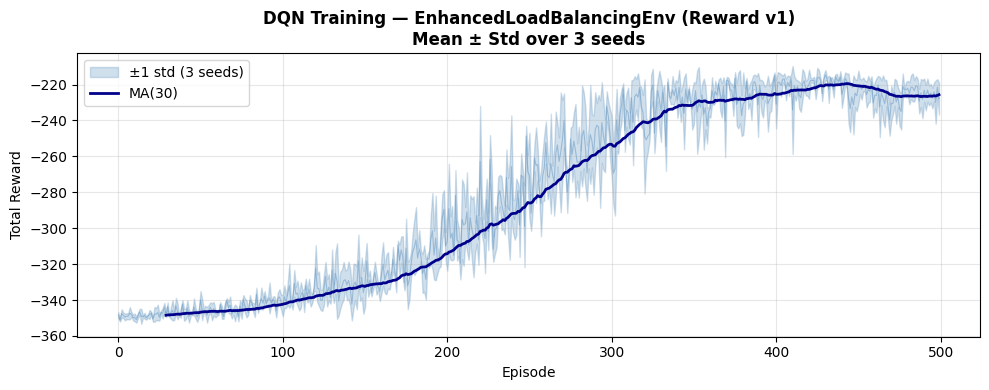

In [17]:

# ============================================================================
# Task 5 — Train DQN on EnhancedLoadBalancingEnv (reward v1, multiple seeds)
# ============================================================================
import time

SEEDS_TRAIN  = [42, 7, 123]        # 3 seeds → show average learning curves
NUM_SERVERS  = 3
STATE_SIZE   = NUM_SERVERS + 2     # 5 = 3 queues + demand + progress
NUM_EPISODES = 500
BATCH_SIZE   = 64

# --- container for per-seed agents & curves ---
all_train_rewards = {}   # seed → list[float]
trained_agents    = {}   # seed → DQNAgent  (best final agent = seed 42)

print("=" * 62)
print("TASK 5 — DQN TRAINING (3 seeds, reward v1)")
print("=" * 62)

for seed in SEEDS_TRAIN:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env_train  = EnhancedLoadBalancingEnv(num_servers=NUM_SERVERS, max_steps=300)
    agent_seed = DQNAgent(
        state_size=STATE_SIZE,
        action_size=NUM_SERVERS,
        learning_rate=5e-4,
        gamma=0.99,
    )
    # Fresh epsilon per seed
    agent_seed.epsilon = 1.0

    ep_rewards = []
    t0 = time.time()

    for ep in range(NUM_EPISODES):
        state, _ = env_train.reset(seed=ep * 1000 + seed)
        ep_r, done = 0.0, False
        while not done:
            action                                   = agent_seed.select_action(state, training=True)
            next_state, r, terminated, truncated, _  = env_train.step(action)
            done                                     = terminated or truncated
            agent_seed.store_transition(state, action, r, next_state, done)
            agent_seed.train_step(BATCH_SIZE)
            ep_r  += r
            state  = next_state
        agent_seed.decay_epsilon()
        ep_rewards.append(ep_r)

        if (ep + 1) % 100 == 0:
            avg = np.mean(ep_rewards[-100:])
            print(f"  [seed={seed}] ep {ep+1:4d}/{NUM_EPISODES} | "
                  f"avg(last 100)={avg:.3f} | ε={agent_seed.epsilon:.3f}")

    elapsed = time.time() - t0
    all_train_rewards[seed] = ep_rewards
    trained_agents[seed]    = agent_seed
    print(f"  ✓ seed={seed} done in {elapsed:.1f}s | "
          f"final avg={np.mean(ep_rewards[-100:]):.3f}\n")

# Use seed-42 agent as the representative DQN policy
agent_dqn_v1 = trained_agents[42]
print("✓ agent_dqn_v1 ready (seed=42)")

# ── Learning curve: mean ± std over 3 seeds ──────────────────────────────────
rewards_array  = np.array([all_train_rewards[s] for s in SEEDS_TRAIN])  # (3, 500)
mean_r         = rewards_array.mean(axis=0)
std_r          = rewards_array.std(axis=0)
window         = 30
mean_ma        = np.convolve(mean_r, np.ones(window) / window, mode='valid')
x_ma           = np.arange(window - 1, NUM_EPISODES)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(
    range(NUM_EPISODES),
    mean_r - std_r, mean_r + std_r,
    alpha=0.25, color='steelblue', label='±1 std (3 seeds)',
)
ax.plot(mean_r,  alpha=0.4, color='steelblue', linewidth=0.8)
ax.plot(x_ma, mean_ma, color='darkblue', linewidth=2, label=f'MA({window})')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title('DQN Training — EnhancedLoadBalancingEnv (Reward v1)\nMean ± Std over 3 seeds',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show(); plt.close(fig)


### 2.7: Task 5 — Evaluation: DQN vs Round Robin (100 episodes × multiple seeds)

In [18]:

# ============================================================================
# Task 5 — Evaluation helper + run 100 episodes per policy per seed
# ============================================================================
import pandas as pd
import os

def run_policy_eval(env, agent, n_episodes=100, base_seed=0, label=''):
    """
    Run agent greedily on env for n_episodes.
    Returns a DataFrame with one row per episode and all required metrics.
    """
    records = []
    for ep in range(n_episodes):
        seed = base_seed * 10000 + ep
        state, _ = env.reset(seed=seed)
        if hasattr(agent, 'reset'):
            agent.reset()
        done = False
        while not done:
            action              = agent.select_action(state, training=False)
            state, _, term, trun, _ = env.step(action)
            done                = term or trun
        m = env.get_episode_metrics()
        m['episode']   = ep + 1
        m['base_seed'] = base_seed
        m['policy']    = label
        records.append(m)
    return pd.DataFrame(records)


EVAL_SEEDS   = [0, 1, 2]     # 3 independent seeds
EVAL_N       = 100            # episodes per seed
NUM_SERVERS  = 3

env_eval = EnhancedLoadBalancingEnv(num_servers=NUM_SERVERS, max_steps=300)
rr_agent = RoundRobinAgent(num_servers=NUM_SERVERS)

dfs_dqn, dfs_rr = [], []

print("Evaluating policies (3 seeds × 100 episodes each)…")
for seed in EVAL_SEEDS:
    df_d = run_policy_eval(env_eval, agent_dqn_v1, EVAL_N, base_seed=seed, label='DQN_v1')
    df_r = run_policy_eval(env_eval, rr_agent,     EVAL_N, base_seed=seed, label='RoundRobin')
    dfs_dqn.append(df_d)
    dfs_rr.append(df_r)
    print(f"  seed={seed} | DQN avg_reward={df_d['total_reward'].mean():.3f} "
          f"| RR avg_reward={df_r['total_reward'].mean():.3f}")

df_dqn_v1 = pd.concat(dfs_dqn, ignore_index=True)   # 300 rows total
df_rr_v1  = pd.concat(dfs_rr,  ignore_index=True)

print(f"\n  DQN_v1  : {len(df_dqn_v1)} episodes across {len(EVAL_SEEDS)} seeds")
print(f"  RoundRobin: {len(df_rr_v1)} episodes across {len(EVAL_SEEDS)} seeds")


Evaluating policies (3 seeds × 100 episodes each)…
  seed=0 | DQN avg_reward=-226.907 | RR avg_reward=-350.400
  seed=1 | DQN avg_reward=-227.023 | RR avg_reward=-350.073
  seed=2 | DQN avg_reward=-226.610 | RR avg_reward=-350.460

  DQN_v1  : 300 episodes across 3 seeds
  RoundRobin: 300 episodes across 3 seeds


In [19]:

# ============================================================================
# Task 5 — Save metrics to CSV + print comparison table
# ============================================================================

METRIC_COLS = [
    'total_time', 'total_tasks_created', 'tasks_accepted',
    'tasks_skipped', 'tasks_completed', 'total_reward',
    'avg_queue_time', 'load_deviation',
    'server_0_freq', 'server_1_freq', 'server_2_freq',
]

METRIC_LABELS = {
    'total_time':          'Tổng thời gian chạy (steps)',
    'total_tasks_created': 'Tổng số tác vụ đã tạo',
    'tasks_accepted':      'Tác vụ được tiếp nhận',
    'tasks_skipped':       'Tác vụ bị bỏ qua (dropped)',
    'tasks_completed':     'Tác vụ đã hoàn thành (approx.)',
    'total_reward':        'Phần thưởng (reward)',
    'avg_queue_time':      'Tổng queue time trung bình',
    'load_deviation':      'Độ lệch tải (std utilization)',
    'server_0_freq':       'Tần suất chọn Server 0',
    'server_1_freq':       'Tần suất chọn Server 1',
    'server_2_freq':       'Tần suất chọn Server 2',
}


def save_metrics_to_csv(df_policy1, df_policy2, tag='v1', out_dir='results_part2'):
    """
    Save per-episode CSVs + a summary comparison CSV.

    Files:
        {out_dir}/dqn_{tag}_episodes.csv
        {out_dir}/rr_{tag}_episodes.csv
        {out_dir}/comparison_{tag}.csv
    """
    os.makedirs(out_dir, exist_ok=True)

    p1_name = df_policy1['policy'].iloc[0]
    p2_name = df_policy2['policy'].iloc[0]

    path_p1  = os.path.join(out_dir, f"{p1_name.lower().replace(' ', '_')}_{tag}_episodes.csv")
    path_p2  = os.path.join(out_dir, f"{p2_name.lower().replace(' ', '_')}_{tag}_episodes.csv")
    path_cmp = os.path.join(out_dir, f"comparison_{tag}.csv")

    df_policy1.to_csv(path_p1,  index=False)
    df_policy2.to_csv(path_p2,  index=False)

    # Build summary
    rows = []
    for col in METRIC_COLS:
        v1 = df_policy1[col]
        v2 = df_policy2[col]
        rows.append({
            'Metric':          METRIC_LABELS.get(col, col),
            f'{p1_name}_mean': round(v1.mean(), 4),
            f'{p1_name}_std':  round(v1.std(),  4),
            f'{p2_name}_mean': round(v2.mean(), 4),
            f'{p2_name}_std':  round(v2.std(),  4),
        })
    df_cmp = pd.DataFrame(rows)
    df_cmp.to_csv(path_cmp, index=False)

    print(f"  Saved: {path_p1}")
    print(f"  Saved: {path_p2}")
    print(f"  Saved: {path_cmp}")
    return df_cmp


print("Saving metrics to CSV…")
df_cmp_v1 = save_metrics_to_csv(df_dqn_v1, df_rr_v1, tag='v1')

# ── Pretty comparison table ────────────────────────────────────────────────
print("\n" + "=" * 78)
print("BẢNG SO SÁNH TỔNG HỢP — DQN_v1 vs Round Robin (300 episodes / 3 seeds)")
print("=" * 78)

dqn_col = 'DQN_v1_mean'
rr_col  = 'RoundRobin_mean'
dqn_std = 'DQN_v1_std'
rr_std  = 'RoundRobin_std'

header = f"{'Metrics':<40} {'DQN_v1 (mean±std)':>22} {'Round Robin (mean±std)':>24}"
print(header)
print("-" * 78)
for _, row in df_cmp_v1.iterrows():
    dqn_s = f"{row[dqn_col]:.3f} ± {row[dqn_std]:.3f}"
    rr_s  = f"{row[rr_col]:.3f} ± {row[rr_std]:.3f}"
    print(f"  {row['Metric']:<38} {dqn_s:>22} {rr_s:>24}")
print("=" * 78)


Saving metrics to CSV…
  Saved: results_part2\dqn_v1_v1_episodes.csv
  Saved: results_part2\roundrobin_v1_episodes.csv
  Saved: results_part2\comparison_v1.csv

BẢNG SO SÁNH TỔNG HỢP — DQN_v1 vs Round Robin (300 episodes / 3 seeds)
Metrics                                       DQN_v1 (mean±std)   Round Robin (mean±std)
------------------------------------------------------------------------------
  Tổng thời gian chạy (steps)                   300.000 ± 0.000          300.000 ± 0.000
  Tổng số tác vụ đã tạo                         300.000 ± 0.000          300.000 ± 0.000
  Tác vụ được tiếp nhận                          56.880 ± 2.128          120.277 ± 3.375
  Tác vụ bị bỏ qua (dropped)                    243.120 ± 2.128          179.723 ± 3.375
  Tác vụ đã hoàn thành (approx.)                 32.750 ± 0.596           71.000 ± 0.000
  Phần thưởng (reward)                         -226.846 ± 1.510         -350.311 ± 2.562
  Tổng queue time trung bình                     35.096 ± 0.329   

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27856\1424796702.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax0.boxplot(data_box, labels=['DQN v1', 'Round Robin'], patch_artist=True,


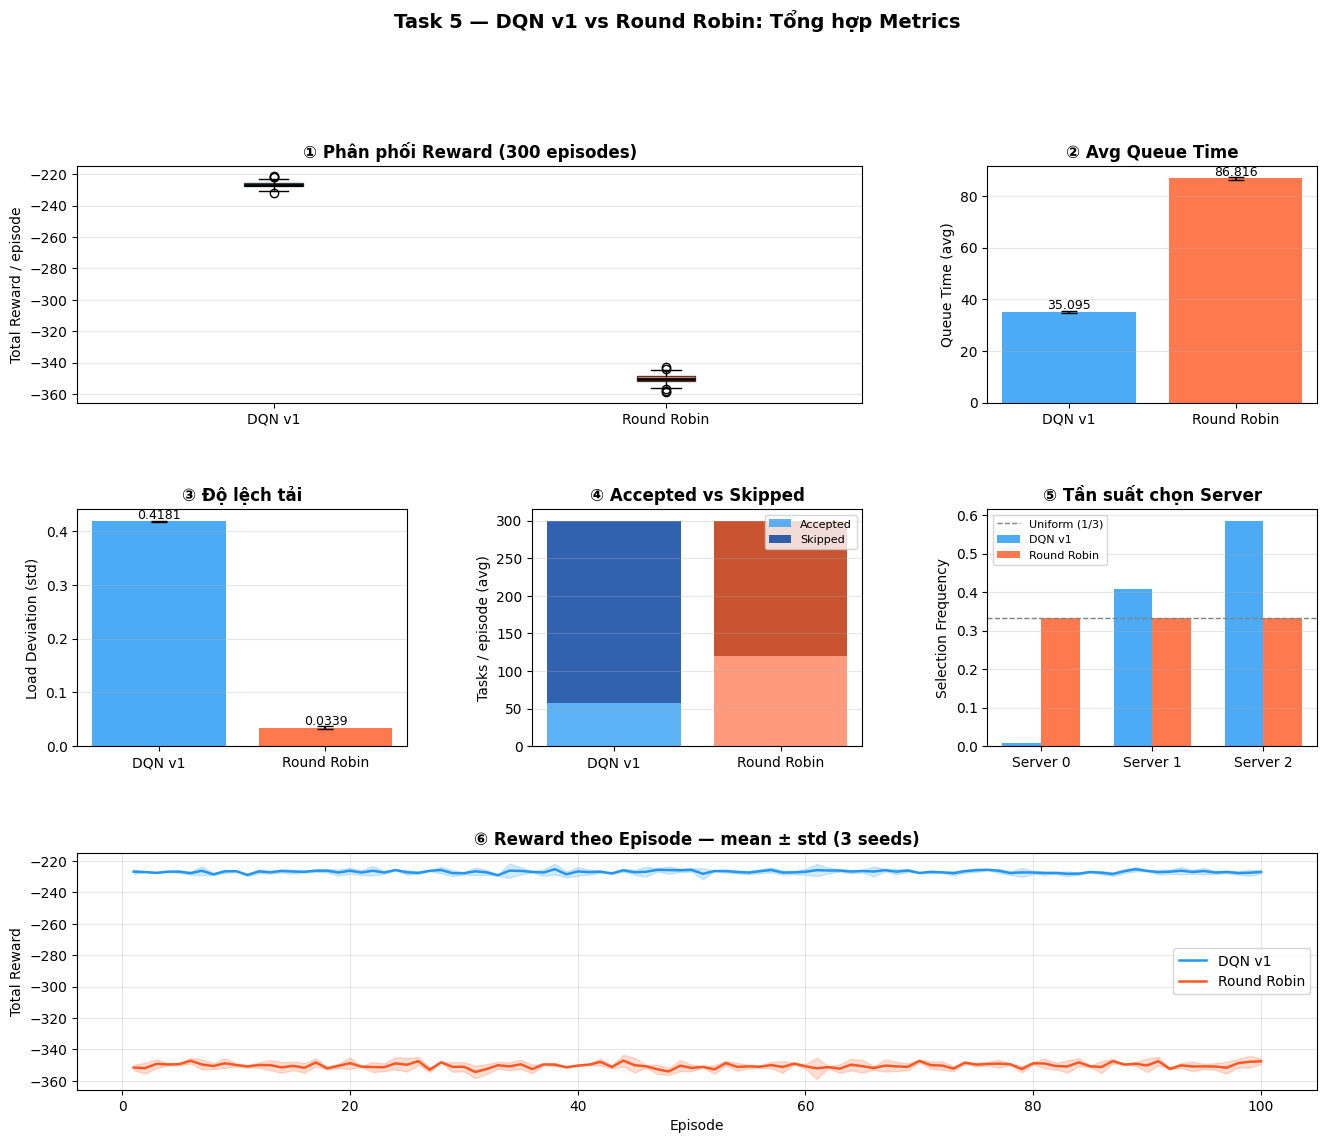

✓ Figure saved → results_part2/task5_comparison_v1.png


In [20]:

# ============================================================================
# Task 5 — Visualization: DQN v1 vs Round Robin
# ============================================================================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

colors = {'DQN_v1': '#2196F3', 'RoundRobin': '#FF5722'}

# ── 1. Reward distribution (box) ─────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
data_box   = [df_dqn_v1['total_reward'].values, df_rr_v1['total_reward'].values]
bp = ax0.boxplot(data_box, labels=['DQN v1', 'Round Robin'], patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], [colors['DQN_v1'], colors['RoundRobin']]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax0.set_ylabel('Total Reward / episode')
ax0.set_title('① Phân phối Reward (300 episodes)', fontweight='bold')
ax0.grid(True, axis='y', alpha=0.3)

# ── 2. Avg queue time bar ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
vals   = [df_dqn_v1['avg_queue_time'].mean(), df_rr_v1['avg_queue_time'].mean()]
stds   = [df_dqn_v1['avg_queue_time'].std(),  df_rr_v1['avg_queue_time'].std()]
labels = ['DQN v1', 'Round Robin']
bars   = ax1.bar(labels, vals, yerr=stds, color=[colors['DQN_v1'], colors['RoundRobin']],
                 alpha=0.8, capsize=6)
ax1.set_ylabel('Queue Time (avg)')
ax1.set_title('② Avg Queue Time', fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# ── 3. Load deviation bar ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
vals2 = [df_dqn_v1['load_deviation'].mean(), df_rr_v1['load_deviation'].mean()]
std2  = [df_dqn_v1['load_deviation'].std(),  df_rr_v1['load_deviation'].std()]
bars2 = ax2.bar(labels, vals2, yerr=std2, color=[colors['DQN_v1'], colors['RoundRobin']],
                alpha=0.8, capsize=6)
ax2.set_ylabel('Load Deviation (std)')
ax2.set_title('③ Độ lệch tải', fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)
for bar, v in zip(bars2, vals2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
             f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# ── 4. Tasks accepted vs skipped (stacked bar) ───────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
cat_labels = ['DQN v1', 'Round Robin']
acc  = [df_dqn_v1['tasks_accepted'].mean(), df_rr_v1['tasks_accepted'].mean()]
skip = [df_dqn_v1['tasks_skipped'].mean(),  df_rr_v1['tasks_skipped'].mean()]
ax3.bar(cat_labels, acc,  label='Accepted', color=['#42A5F5', '#FF8A65'], alpha=0.85)
ax3.bar(cat_labels, skip, bottom=acc, label='Skipped', color=['#0D47A1', '#BF360C'], alpha=0.85)
ax3.set_ylabel('Tasks / episode (avg)')
ax3.set_title('④ Accepted vs Skipped', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, axis='y', alpha=0.3)

# ── 5. Server selection frequency ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
freq_dqn = [df_dqn_v1[f'server_{i}_freq'].mean() for i in range(3)]
freq_rr  = [df_rr_v1[f'server_{i}_freq'].mean()  for i in range(3)]
x_pos    = np.arange(3)
width    = 0.35
ax4.bar(x_pos - width/2, freq_dqn, width, label='DQN v1',     color=colors['DQN_v1'], alpha=0.8)
ax4.bar(x_pos + width/2, freq_rr,  width, label='Round Robin', color=colors['RoundRobin'], alpha=0.8)
ax4.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Uniform (1/3)')
ax4.set_xticks(x_pos); ax4.set_xticklabels(['Server 0', 'Server 1', 'Server 2'])
ax4.set_ylabel('Selection Frequency')
ax4.set_title('⑤ Tần suất chọn Server', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, axis='y', alpha=0.3)

# ── 6. Reward episode curve (mean across seeds) ───────────────────────────
ax5 = fig.add_subplot(gs[2, :])
for df_ep, lbl, col in [
    (df_dqn_v1, 'DQN v1',     colors['DQN_v1']),
    (df_rr_v1,  'Round Robin', colors['RoundRobin']),
]:
    per_ep = df_ep.groupby('episode')['total_reward'].agg(['mean', 'std'])
    ax5.fill_between(per_ep.index,
                     per_ep['mean'] - per_ep['std'],
                     per_ep['mean'] + per_ep['std'],
                     alpha=0.2, color=col)
    ax5.plot(per_ep.index, per_ep['mean'], color=col, linewidth=1.8, label=lbl)
ax5.set_xlabel('Episode'); ax5.set_ylabel('Total Reward')
ax5.set_title('⑥ Reward theo Episode — mean ± std (3 seeds)', fontweight='bold')
ax5.legend(); ax5.grid(True, alpha=0.3)

fig.suptitle('Task 5 — DQN v1 vs Round Robin: Tổng hợp Metrics',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('results_part2/task5_comparison_v1.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)
print("✓ Figure saved → results_part2/task5_comparison_v1.png")


In [36]:

# ============================================================================
# Task 6 — LoadBalancingEnvV2 with Reward v2 (redesigned)
# ============================================================================

class LoadBalancingEnvV2(EnhancedLoadBalancingEnv):
    """
ả     Reward v2: giữ nguyên scale v1, thêm routing shaping nhỏ.

        r = −avg_q_norm
            + (−0.5 if dropped else 0)
            + 0.3 × (1 − queue[action] / CAPACITY)

    Thành phần thứ 3: bonus [0, 0.3] tỉ lệ với "độ nhàn" của server được chọn.
        = 0.3  khi chọn server hoàn toàn trống → khuyến khích dùng server ít tải
        = 0.0  khi chọn server đầy tối đa
    Cùng scale với avg_q_norm → không dominate, không gây mất ổn định học.
    """

    def step(self, action):
        self.steps += 1

        # --- lưu queue trước khi route ---
        q_action_before = float(self.queues[action])

        # --- generate task ---
        task_demand           = float(np.random.uniform(self.MIN_DEMAND, self.MAX_DEMAND))
        self.current_demand   = task_demand
        self._m['tasks_created']           += 1
        self._m['selection_count'][action] += 1

        # --- route ---
        if self.queues[action] + task_demand <= self.CAPACITY:
            self.queues[action]       += task_demand
            self._m['tasks_accepted'] += 1
            accepted = True
        else:
            self._m['tasks_skipped']  += 1
            accepted = False

        # --- process ---
        processed = 0.0
        for i in range(self.num_servers):
            proc             = min(self.queues[i], 1.0)
            self.queues[i]   = max(0.0, self.queues[i] - 1.0)
            processed       += proc
        self._m['completed_work'] += processed

        # --- metrics bookkeeping ---
        total_q = float(np.sum(self.queues))
        self._m['queue_sum']     += total_q
        util                     = self.queues / self.CAPACITY
        self._m['queue_std_sum'] += float(np.std(util))

        # ── Reward v2 ──────────────────────────────────────────────────
        avg_q_norm    = total_q / (self.num_servers * self.CAPACITY)
        drop_penalty  = -0.5 if not accepted else 0.0
        routing_bonus = 0.3 * (1.0 - q_action_before / self.CAPACITY)  # ∈ [0, 0.3]

        reward = -avg_q_norm + drop_penalty + routing_bonus

        self._m['total_reward'] += reward

        terminated = False
        truncated  = self.steps >= self.max_steps
        return self._get_state(), reward, terminated, truncated, {
            'accepted': accepted, 'demand': task_demand
        }


_env_v2 = LoadBalancingEnvV2(num_servers=3)
_obs, _ = _env_v2.reset(seed=0)
_, r2, *_ = _env_v2.step(0)
print(f"✓ LoadBalancingEnvV2 (reward v2) defined | sample reward: {r2:.4f}")
print("  r = −avg_q_norm  + (−0.5 if dropped)  + 0.3×(1−q_action/CAP)")


✓ LoadBalancingEnvV2 (reward v2) defined | sample reward: 0.2453
  r = −avg_q_norm  + (−0.5 if dropped)  + 0.3×(1−q_action/CAP)


In [ ]:

# ============================================================================
# Task 6 — Train DQN on Reward v2 env (3 seeds)
# ============================================================================

all_train_rewards_v2 = {}
trained_agents_v2    = {}

print("=" * 62)
print("TASK 6 — DQN TRAINING (3 seeds, reward v2)")
print("=" * 62)

for seed in SEEDS_TRAIN:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    env_v2  = LoadBalancingEnvV2(num_servers=NUM_SERVERS, max_steps=300)
    agent_v2 = DQNAgent(
        state_size=STATE_SIZE,
        action_size=NUM_SERVERS,
        learning_rate=5e-4,
        gamma=0.99,
    )
    agent_v2.epsilon = 1.0

    ep_rewards_v2 = []
    t0 = time.time()

    for ep in range(NUM_EPISODES):
        state, _ = env_v2.reset(seed=ep * 1000 + seed)
        ep_r, done = 0.0, False
        while not done:
            action                                  = agent_v2.select_action(state, training=True)
            next_state, r, terminated, truncated, _ = env_v2.step(action)
            done                                    = terminated or truncated
            agent_v2.store_transition(state, action, r, next_state, done)
            agent_v2.train_step(BATCH_SIZE)
            ep_r  += r
            state  = next_state
        agent_v2.decay_epsilon()
        ep_rewards_v2.append(ep_r)

        if (ep + 1) % 100 == 0:
            avg = np.mean(ep_rewards_v2[-100:])
            print(f"  [seed={seed}] ep {ep+1:4d}/{NUM_EPISODES} | "
                  f"avg={avg:.3f} | ε={agent_v2.epsilon:.3f}")

    elapsed = time.time() - t0
    all_train_rewards_v2[seed] = ep_rewards_v2
    trained_agents_v2[seed]    = agent_v2
    print(f"  ✓ seed={seed} done in {elapsed:.1f}s | "
          f"final avg={np.mean(ep_rewards_v2[-100:]):.3f}\n")

agent_dqn_v2 = trained_agents_v2[42]
print("✓ agent_dqn_v2 ready (seed=42)")

# ── Compare v1 vs v2 training curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

for ax, all_r, label, color in [
    (axes[0], all_train_rewards,    'DQN v1 (original reward)',  'steelblue'),
    (axes[1], all_train_rewards_v2, 'DQN v2 (redesigned reward)', 'darkorange'),
]:
    arr     = np.array([all_r[s] for s in SEEDS_TRAIN])
    mean_r  = arr.mean(axis=0)
    std_r   = arr.std(axis=0)
    window  = 30
    ma      = np.convolve(mean_r, np.ones(window)/window, mode='valid')
    x_ma    = np.arange(window - 1, NUM_EPISODES)
    ax.fill_between(range(NUM_EPISODES), mean_r - std_r, mean_r + std_r,
                    alpha=0.2, color=color)
    ax.plot(mean_r, alpha=0.35, color=color, linewidth=0.8)
    ax.plot(x_ma, ma, color=color, linewidth=2, label=f'MA({window})')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves: Reward v1 vs v2 (mean ± std, 3 seeds)', fontweight='bold')
plt.tight_layout()
plt.savefig('results_part2/task6_training_curves.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close(fig)
print("✓ Figure saved → results_part2/task6_training_curves.png")


In [33]:

# ============================================================================
# Task 6 — Evaluate DQN v2 vs Round Robin + compare with DQN v1
# Evaluation on the SAME EnhancedLoadBalancingEnv (neutral env) so comparison is fair
# ============================================================================

# Note: we evaluate ALL agents on the reward-v1 env to get comparable metrics.
env_neutral = EnhancedLoadBalancingEnv(num_servers=NUM_SERVERS, max_steps=300)

dfs_dqn_v2 = []
print("Evaluating DQN v2 policy (3 seeds × 100 episodes)…")
for seed in EVAL_SEEDS:
    df_d2 = run_policy_eval(env_neutral, agent_dqn_v2, EVAL_N, base_seed=seed, label='DQN_v2')
    dfs_dqn_v2.append(df_d2)
    print(f"  seed={seed} | DQN_v2 avg_reward={df_d2['total_reward'].mean():.3f}")

df_dqn_v2 = pd.concat(dfs_dqn_v2, ignore_index=True)

# Save v2 metrics
print("\nSaving DQN v2 metrics…")
df_cmp_v2 = save_metrics_to_csv(df_dqn_v2, df_rr_v1, tag='v2')

# ── Side-by-side comparison: DQN v1 vs DQN v2 vs Round Robin ─────────────
print("\n" + "=" * 88)
print("BẢNG SO SÁNH: DQN v1 vs DQN v2 vs Round Robin (300 episodes / 3 seeds)")
print("=" * 88)

def agg(df, col):
    return f"{df[col].mean():.3f} ± {df[col].std():.3f}"

col_w = 38
print(f"{'Metrics':<{col_w}} {'DQN v1':>22} {'DQN v2':>22} {'Round Robin':>22}")
print("-" * 88)
for col in METRIC_COLS:
    label = METRIC_LABELS.get(col, col)
    print(f"  {label:<{col_w-2}} {agg(df_dqn_v1, col):>22} {agg(df_dqn_v2, col):>22} {agg(df_rr_v1, col):>22}")
print("=" * 88)


Evaluating DQN v2 policy (3 seeds × 100 episodes)…
  seed=0 | DQN_v2 avg_reward=-239.891
  seed=1 | DQN_v2 avg_reward=-239.813
  seed=2 | DQN_v2 avg_reward=-239.548

Saving DQN v2 metrics…
  Saved: results_part2\dqn_v2_v2_episodes.csv
  Saved: results_part2\roundrobin_v2_episodes.csv
  Saved: results_part2\comparison_v2.csv

BẢNG SO SÁNH: DQN v1 vs DQN v2 vs Round Robin (300 episodes / 3 seeds)
Metrics                                                DQN v1                 DQN v2            Round Robin
----------------------------------------------------------------------------------------
  Tổng thời gian chạy (steps)                 300.000 ± 0.000        300.000 ± 0.000        300.000 ± 0.000
  Tổng số tác vụ đã tạo                       300.000 ± 0.000        300.000 ± 0.000        300.000 ± 0.000
  Tác vụ được tiếp nhận                        56.880 ± 2.128         62.020 ± 2.223        120.277 ± 3.375
  Tác vụ bị bỏ qua (dropped)                  243.120 ± 2.128        237.980 ± 2.

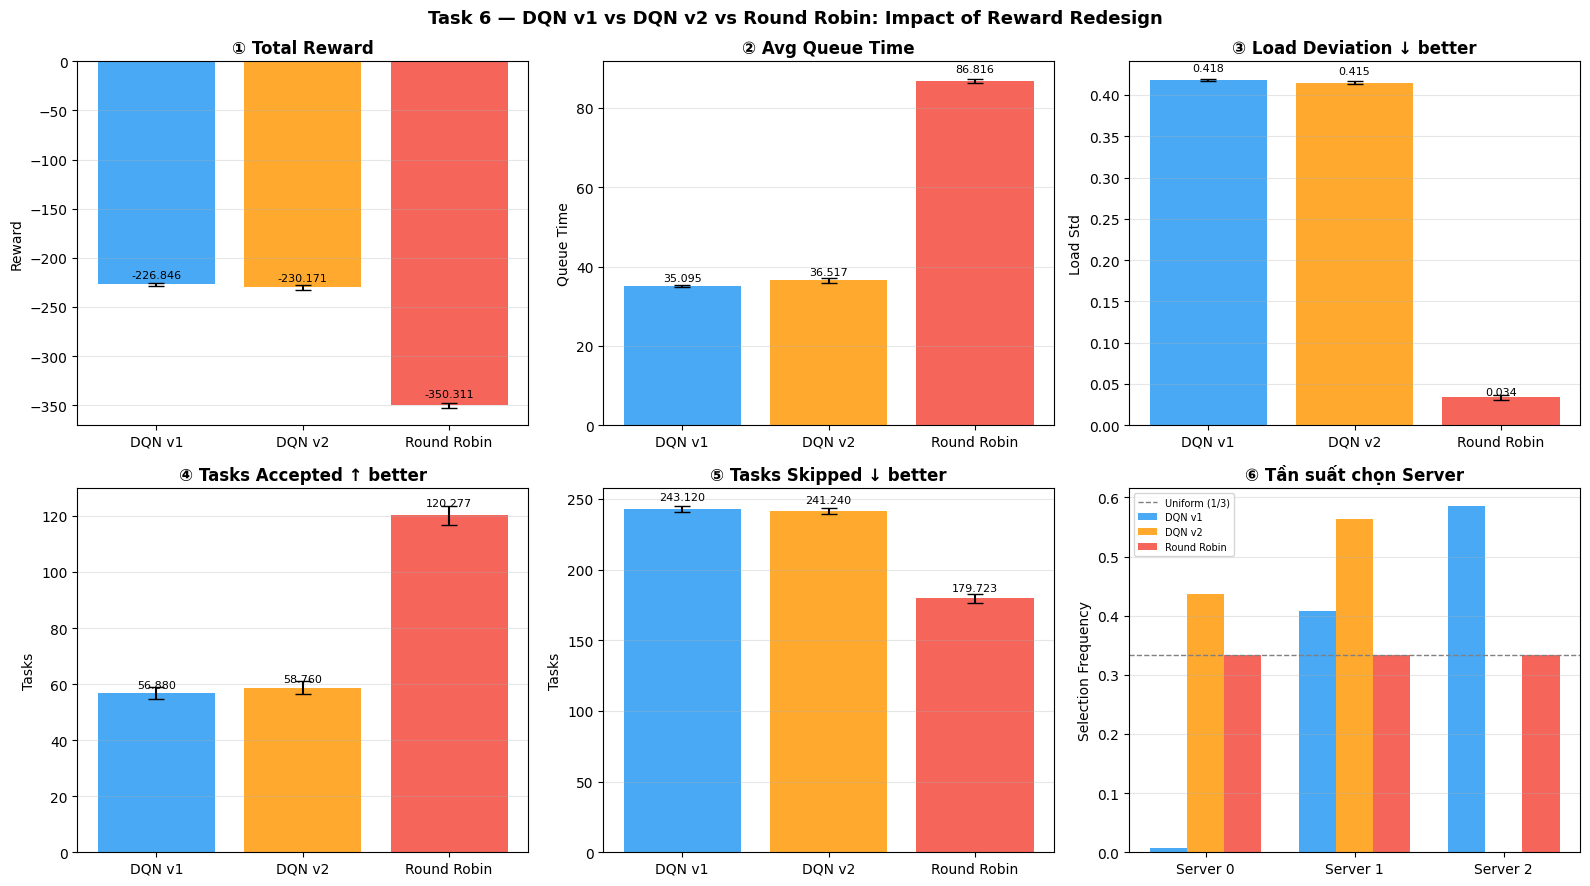

✓ Figure saved → results_part2/task6_final_comparison.png


In [23]:

# ============================================================================
# Task 6 — Final visualization: 3-policy comparison (radar + bar charts)
# ============================================================================

labels_3 = ['DQN v1', 'DQN v2', 'Round Robin']
dfs_3    = [df_dqn_v1, df_dqn_v2, df_rr_v1]
colors_3 = ['#2196F3', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Task 6 — DQN v1 vs DQN v2 vs Round Robin: Impact of Reward Redesign',
             fontsize=13, fontweight='bold')

# Helper: simple grouped bar
def grouped_bar(ax, col, ylabel, title):
    vals = [df[col].mean() for df in dfs_3]
    errs = [df[col].std()  for df in dfs_3]
    bars = ax.bar(labels_3, vals, yerr=errs, color=colors_3, alpha=0.82, capsize=6)
    ax.set_ylabel(ylabel); ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + abs(v)*0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

grouped_bar(axes[0,0], 'total_reward',  'Reward',        '① Total Reward')
grouped_bar(axes[0,1], 'avg_queue_time','Queue Time',    '② Avg Queue Time')
grouped_bar(axes[0,2], 'load_deviation','Load Std',      '③ Load Deviation ↓ better')
grouped_bar(axes[1,0], 'tasks_accepted','Tasks',         '④ Tasks Accepted ↑ better')
grouped_bar(axes[1,1], 'tasks_skipped', 'Tasks',         '⑤ Tasks Skipped ↓ better')

# ── Server selection frequency (grouped bar by server) ────────────────────
ax5 = axes[1, 2]
x_pos = np.arange(3)
width = 0.25
for i, (df_p, label, col) in enumerate(zip(dfs_3, labels_3, colors_3)):
    freqs = [df_p[f'server_{j}_freq'].mean() for j in range(NUM_SERVERS)]
    ax5.bar(x_pos + (i - 1) * width, freqs, width, label=label, color=col, alpha=0.82)
ax5.axhline(1/3, color='gray', linestyle='--', linewidth=1, label='Uniform (1/3)')
ax5.set_xticks(x_pos); ax5.set_xticklabels(['Server 0', 'Server 1', 'Server 2'])
ax5.set_ylabel('Selection Frequency')
ax5.set_title('⑥ Tần suất chọn Server', fontweight='bold')
ax5.legend(fontsize=7); ax5.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_part2/task6_final_comparison.png', dpi=120, bbox_inches='tight')
plt.show(); plt.close(fig)
print("✓ Figure saved → results_part2/task6_final_comparison.png")


---

# PART 3: DQN with Stable-Baselines3

Production-ready implementation using the Stable-Baselines3 library. This is more efficient and less error-prone than manual implementation.

### 3.1: Import Stable-Baselines3

In [ ]:
# ============================================================================
# Part 3 setup for SB3
# ============================================================================
# We keep this implementation simple and use FrozenLake-v1 (as in Lab 3.1).

print("\n" + "="*60)
print("PART 3: STABLE-BASELINES3 DQN ON FROZENLAKE-V1")
print("="*60)

print("\n3.1: Import Stable-Baselines3")
print("-" * 60)

try:
    from stable_baselines3 import DQN
    sb3_available = True
    print("✓ Stable-Baselines3 imported successfully")
except Exception as e:
    sb3_available = False
    print("⚠ SB3 import failed in this environment")
    print(f"  Error: {type(e).__name__}: {e}")
    print("  Please check package compatibility in env nt549-1-phatpt.")

### 3.2: Train SB3 DQN on FrozenLake-v1 (Simple)

In [ ]:
# ============================================================================
# Part 3 train/eval with SB3 on FrozenLake-v1
# ============================================================================

if sb3_available:
    print("\n3.2: Training SB3 DQN on FrozenLake-v1")
    print("-" * 60)

    ### YOU NEED TO WRITE YOUR CODE BELOW ###
    # 1) Create FrozenLake-v1 environment
    # 2) Initialize SB3 DQN model
    # 3) Train model with suitable timesteps
    env_sb3 = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)

    model = DQN(
        policy='MlpPolicy',
        env=env_sb3,
        learning_rate=1e-3,
        buffer_size=5000,
        learning_starts=200,
        batch_size=32,
        gamma=0.99,
        train_freq=4,
        target_update_interval=250,
        verbose=0
    )

    total_timesteps = 10000
    print(f"Training for {total_timesteps} timesteps...\n")
    model.learn(total_timesteps=total_timesteps)
    print("Training completed!\n")

    print("3.3: Evaluation of SB3 DQN on FrozenLake-v1")
    print("-" * 60)

    eval_episodes = 30
    sb3_eval_rewards = []

    for _ in range(eval_episodes):
        obs, _ = env_sb3.reset()
        done = False
        episode_reward = 0.0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            if isinstance(action, np.ndarray):
                action = int(action.item())
            obs, reward, terminated, truncated, _ = env_sb3.step(action)
            done = terminated or truncated
            episode_reward += reward

        sb3_eval_rewards.append(episode_reward)

    success_rate = sum(1 for r in sb3_eval_rewards if r > 0) / eval_episodes * 100
    print("SB3 Evaluation Results:")
    print(f"  Average Reward: {np.mean(sb3_eval_rewards):.2f}")
    print(f"  Success Rate: {success_rate:.1f}%")
    print(f"  Min Reward: {np.min(sb3_eval_rewards):.2f}")
    print(f"  Max Reward: {np.max(sb3_eval_rewards):.2f}")

    env_sb3.close()
else:
    print("\n⚠ Skipping SB3 training because SB3 import was not successful.")


### 3.4: Key Advantages of Stable-Baselines3

Summary of benefits of using production-ready RL libraries.

In [ ]:
# ============================================================================
# Part 3 concept summary
# ============================================================================
# Keep this as a teaching recap slide in code form (easy to run/print).

print("\n3.4: Key Advantages of Stable-Baselines3")
print("="*60)

print("""
1. Optimized Implementation:
   - Highly optimized algorithms (better than manual implementation)
   - Less error-prone (extensively tested)
   - Better hyperparameter tuning utilities

2. Features:
   - Built-in support for multiple algorithms
   - Vectorized environment support
   - Automatic GPU acceleration
   - Callbacks and monitoring

3. Production Ready:
   - Used in industry and research
   - Active community and support
   - Benchmarked and validated

4. When to Use:
   - Quick prototyping: Use SB3
   - Learning fundamentals: Use manual implementation
   - Production systems: Use SB3
   - Custom algorithms: Use PyTorch/TensorFlow directly
""")

print("="*60)

---

# PART 4: Student Exercise - SB3 DQN on VacuumCleanerEnv

In this part, you will implement SB3 DQN directly on `VacuumCleanerEnv`.
Focus on:
1. environment setup
2. model configuration
3. training
4. evaluation and comparison with Part 1 manual DQN


### 4.1: Implement SB3 DQN for VacuumCleanerEnv

Follow the comments carefully and complete all TODO blocks.


In [ ]:
print("\n" + "="*60)
print("PART 4: SB3 DQN ON VACUUMCLEANERENV")
print("="*60)

# Step 1: Create environment
### YOU NEED TO WRITE YOUR CODE BELOW ###
env_sb3_vacuum = None

# Step 2: Build SB3 DQN model
# Suggested parameters to try:
# - learning_rate: 1e-3 or 5e-4
# - buffer_size: 10000 or 20000
# - batch_size: 32 or 64
### YOU NEED TO WRITE YOUR CODE BELOW ###
model_sb3_vacuum = None

# Step 3: Train
### YOU NEED TO WRITE YOUR CODE BELOW ###
total_timesteps = 50000
# model_sb3_vacuum.learn(total_timesteps=total_timesteps)

print("Training finished (if implemented).")


### 4.2: Evaluate SB3 on VacuumCleanerEnv

Compute average reward, clean ratio, and completion rate over multiple episodes.


In [ ]:
# Evaluation template
### YOU NEED TO WRITE YOUR CODE BELOW ###
# Suggested structure:
# eval_episodes = 30
# rewards = []
# clean_ratios = []
# completions = []
# for _ in range(eval_episodes):
# 
#     # collect metrics from environment

print("Please complete evaluation code for Part 4.")


---

## Summary and Key Takeaways

## CONGRATULATIONS TEAM!

Congratulations on completing Lab 03.2 - Introduction to Deep Q-Network!

You have successfully:
- Designed and implemented custom Gymnasium environments (VacuumCleanerEnv, LoadBalancingEnv)
- Trained DQN agents on multiple custom environments
- Learned how to use Stable-Baselines3 for production-ready RL
- Compared manual vs. library-based implementations
- Evaluated agents and visualized training progress

You now have the skills to apply DQN to real-world problems!

References: https://gymnasium.farama.org/ | https://stable-baselines3.readthedocs.io/

## ADDITIONAL INFORMATION

**Author**: M.Sc. Phan Trung Phat - Department of Computer Networks and Communications, UIT

**Contact**: phatpt@uit.edu.vn

**Last Updated**: March, 2026